# eBPF Performance Bottleneck Analysis

Each row = one (pid, cpu) observation from one collection session.
No grouping by process — we treat every row as a feature vector and ask:
**do the metric values differ between bottleneck types?**

That is exactly what the ML classifier will learn.

**Notebook flow:**
1. Config & style
2. Load raw CSV
3. Clean: sparsity filter + outlier cap → `df_clean`
4. Figures 1–6 all use `df_clean`
5. Summary stats

## Cell 1 — Config & style

In [40]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import numpy as np
import os

%matplotlib inline
plt.rcParams['figure.dpi'] = 110

CSV_PATH = 'perf_metrics.csv'
OUT_DIR  = './plots'
os.makedirs(OUT_DIR, exist_ok=True)

BG    = '#0d1117'
AXES  = '#161b22'
GRID  = '#21262d'
TEXT  = '#c9d1d9'
MUTED = '#484f58'

LABEL_COLORS = {
    'cpu_bound':    '#f87171',
    'memory_bound': '#60a5fa',
    'io_bound':     '#4ade80',
    'contention':   '#fb923c',
    'mixed':        '#c084fc',
    'normal_idle':  '#94a3b8',
    'normal_light': '#cbd5e1',
    'normal_mixed': '#64748b',
    'unknown':      '#6b7280',
}
C = ['#60a5fa','#f87171','#4ade80','#fb923c','#c084fc','#facc15','#34d399','#f472b6']

plt.rcParams.update({
    'figure.facecolor': BG,  'axes.facecolor':  AXES,
    'axes.edgecolor':  GRID,  'axes.labelcolor': TEXT,
    'axes.titlecolor': TEXT,  'xtick.color':     MUTED,
    'ytick.color':     MUTED, 'text.color':      TEXT,
    'grid.color':      GRID,  'grid.linewidth':  0.6,
    'lines.linewidth': 1.2,   'font.family':     'monospace',
    'font.size':       10,    'axes.titlesize':  11,
    'axes.labelsize':  9,     'legend.facecolor':AXES,
    'legend.edgecolor':GRID,  'legend.labelcolor':TEXT,
    'legend.fontsize': 8,     'savefig.bbox':    'tight',
    'savefig.facecolor':BG,   'savefig.dpi':     150,
})

def savefig(fig, name):
    fig.savefig(os.path.join(OUT_DIR, name))
    print(f'saved → {OUT_DIR}/{name}')

def legend_patches(label_list):
    return [Patch(color=LABEL_COLORS.get(l, MUTED), alpha=0.8, label=l) for l in label_list]

print('Config ready.')

Config ready.


## Cell 2 — Load raw data

In [41]:
df_raw = pd.read_csv(CSV_PATH)
print(f'Loaded {len(df_raw):,} rows, {len(df_raw.columns)} columns')

# ns → µs for readability
for c in [col for col in df_raw.columns if col.endswith('_ns')]:
    df_raw[c.replace('_ns','_us')] = df_raw[c] / 1000.0

# derived columns
df_raw['total_faults'] = df_raw.get('minor_faults', 0) + df_raw.get('kernel_faults', 0)
df_raw['total_lock_contentions'] = (
    df_raw.get('mutex_contentions', 0) +
    df_raw.get('rwsem_read_contentions', 0) +
    df_raw.get('rwsem_write_contentions', 0)
)
# involuntary % — key CPU bottleneck indicator
df_raw['involuntary_pct'] = np.where(
    df_raw['ctx_switches'] > 0,
    df_raw['involuntary_switches'] / df_raw['ctx_switches'] * 100, 0
)

df_raw['label'] = df_raw['label'].fillna('unknown')

print(f'Raw rows per label:')
print(df_raw['label'].value_counts().to_string())

Loaded 101,993 rows, 41 columns
Raw rows per label:
label
io_bound        32315
memory_bound    17679
contention      15920
cpu_bound       15036
normal_light     7920
normal_idle      7439
normal_mixed     5684


---
## Cell 3 — Clean: sparsity filter + outlier cap

**Step 1 — Sparsity filter:** drop rows where ALL key activity columns are zero.
These are background kernel threads captured by the scheduler probe but with no
memory / syscall / lock activity — pure noise with no discriminating signal.

**Step 2 — Outlier cap:** clip each feature at its global 99th percentile.
Does NOT drop rows — just prevents one extreme session (e.g. fork32 lock spike,
mem_1 page fault burst) from collapsing all other variation to zero in plots
and model training.

Result: `df_clean` — used for all figures and model training from here on.
`df_raw` is preserved for diagnostics.

In [42]:
# ── Step 1: sparsity filter ───────────────────────────────────────────────────
activity_cols = [
    'ctx_switches', 'minor_faults', 'total_alloc_bytes',
    'avg_syscall_latency_ns', 'futex_count', 'total_lock_contentions',
]
activity_cols = [c for c in activity_cols if c in df_raw.columns]

mask_active = (df_raw[activity_cols] > 0).any(axis=1)
df_clean = df_raw[mask_active].copy().reset_index(drop=True)
print(f'Sparsity filter: {len(df_raw):,} → {len(df_clean):,} rows '
      f'(dropped {len(df_raw) - len(df_clean):,} all-zero rows, '
      f'{(len(df_raw)-len(df_clean))/len(df_raw)*100:.1f}%)')

# ── Step 2: 99th percentile cap ──────────────────────────────────────────────
cap_cols = [
    'ctx_switches', 'involuntary_switches', 'voluntary_switches',
    'cpu_migrations', 'total_runtime_ns', 'total_runtime_us',
    'avg_runq_latency_us', 'max_runq_latency_us',
    'minor_faults', 'kernel_faults',
    'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'total_free_bytes', 'large_page_allocs',
    'syscall_count', 'avg_syscall_latency_us', 'max_syscall_latency_us',
    'read_count', 'write_count', 'read_bytes', 'write_bytes',
    'mmap_count', 'futex_count', 'avg_futex_latency_us',
    'epoll_count', 'avg_epoll_latency_us',
    'mutex_contentions', 'avg_mutex_wait_us', 'max_mutex_wait_us',
    'total_faults', 'total_lock_contentions', 'involuntary_pct',
    'avg_runq_latency_ns', 'avg_syscall_latency_ns',
]
cap_cols = [c for c in cap_cols if c in df_clean.columns]

for col in cap_cols:
    p99 = df_clean[col].quantile(0.99)
    if p99 > 0:
        df_clean[col] = df_clean[col].clip(upper=p99)

print(f'Outlier cap: clipped {len(cap_cols)} columns at 99th percentile.')

# row index for scatter plots
df_clean['row_idx'] = np.arange(len(df_clean))

labels = sorted(df_clean['label'].unique())
print(f'\nLabels: {labels}')
print(f'Rows per label after cleaning:')
print(df_clean['label'].value_counts().to_string())

# cap report
print('\nCap thresholds for key features:')
report_cols = ['ctx_switches', 'total_faults', 'total_alloc_bytes',
               'avg_syscall_latency_us', 'total_lock_contentions', 'avg_runq_latency_us']
report_cols = [c for c in report_cols if c in df_clean.columns]
for col in report_cols:
    raw_max = df_raw[col].max()
    capped_max = df_clean[col].max()
    n_capped = (df_raw[mask_active][col] > capped_max).sum()
    print(f'  {col:<35} cap={capped_max:>12.0f}  raw_max={raw_max:>12.0f}  capped={n_capped} rows')

Sparsity filter: 101,993 → 101,789 rows (dropped 204 all-zero rows, 0.2%)
Outlier cap: clipped 35 columns at 99th percentile.

Labels: ['contention', 'cpu_bound', 'io_bound', 'memory_bound', 'normal_idle', 'normal_light', 'normal_mixed']
Rows per label after cleaning:
label
io_bound        32248
memory_bound    17620
contention      15895
cpu_bound       15019
normal_light     7898
normal_idle      7435
normal_mixed     5674

Cap thresholds for key features:
  ctx_switches                        cap=      369661  raw_max=     5712878  capped=1018 rows
  total_faults                        cap=        3619  raw_max=    11315353  capped=1018 rows
  total_alloc_bytes                   cap=     2079665  raw_max= 52790823008  capped=1018 rows
  avg_syscall_latency_us              cap=     1000085  raw_max=   114495486  capped=1018 rows
  total_lock_contentions              cap=       16100  raw_max=      675185  capped=1018 rows
  avg_runq_latency_us                 cap=        1767  raw_ma

---
## Figure 1 — Raw metric values across all rows, coloured by label

X axis = row index (sequence order, after cleaning).  
Each dot = one (pid, cpu) observation.  
**If labels cluster separately on Y → that metric is a good bottleneck signal.**

saved → ./plots/01_scatter_by_label.png


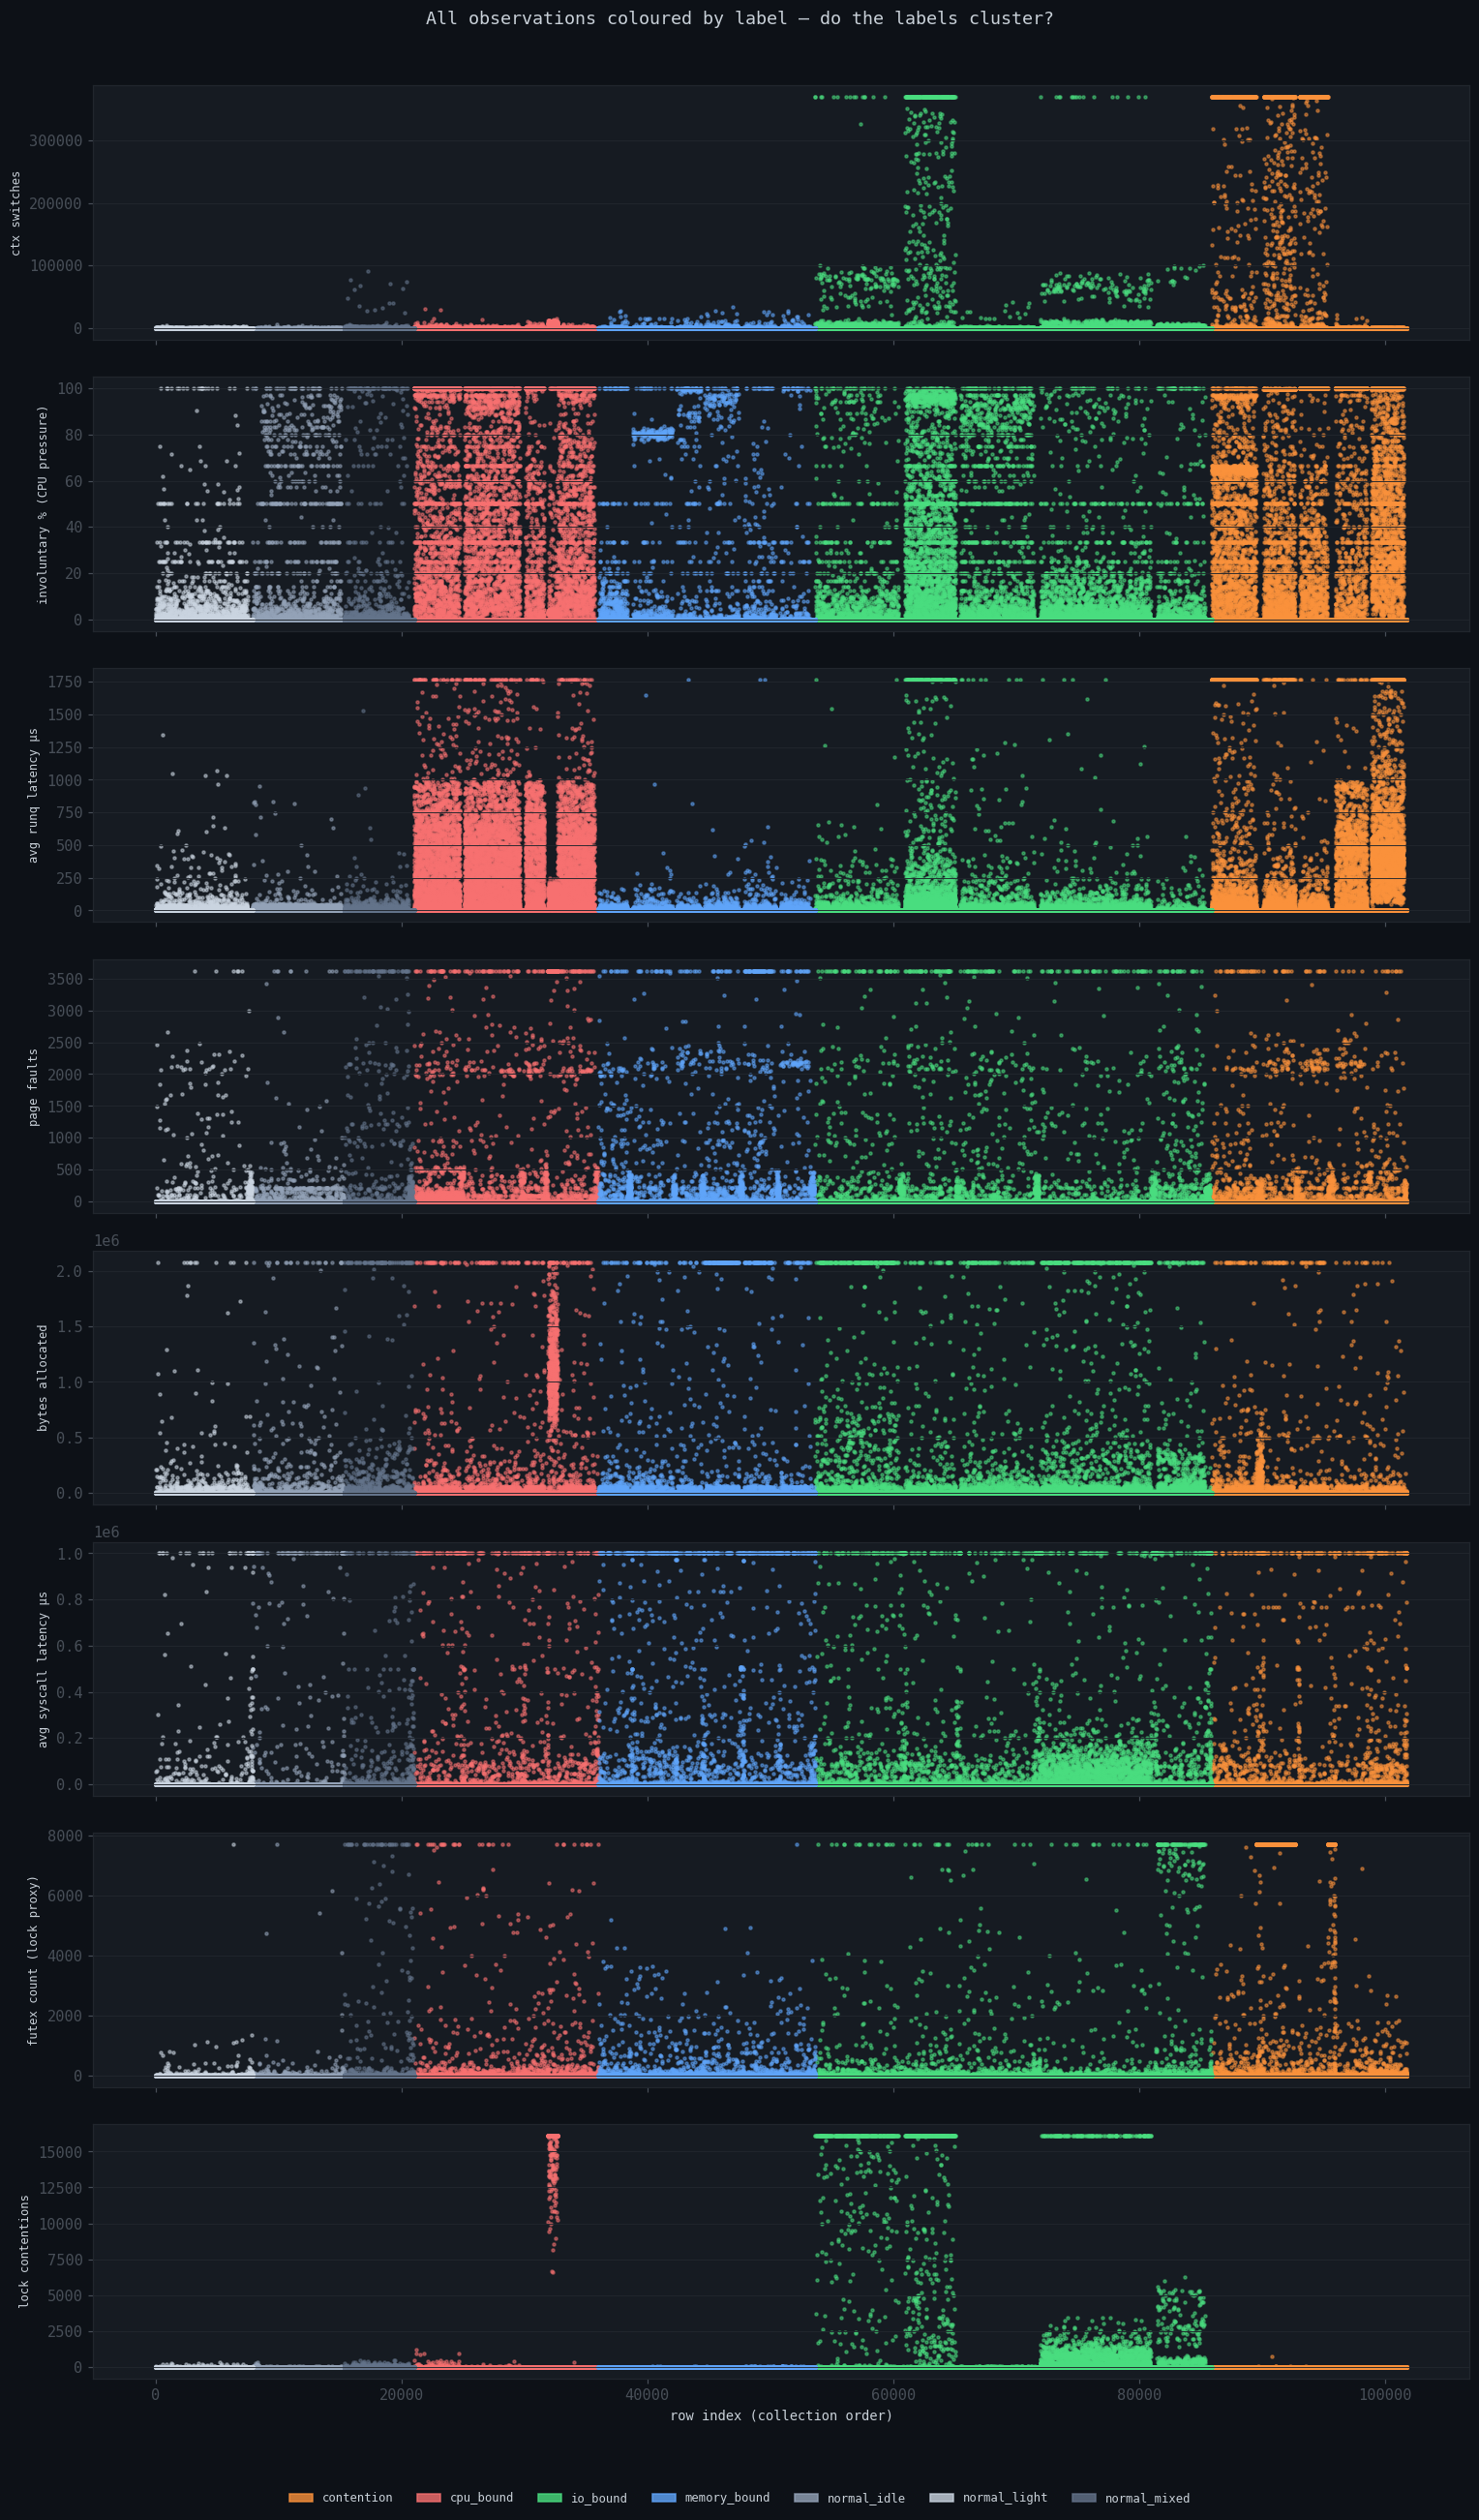

In [43]:
key_metrics = [
    ('ctx_switches',           'ctx switches'),
    ('involuntary_pct',        'involuntary % (CPU pressure)'),
    ('avg_runq_latency_us',    'avg runq latency µs'),
    ('total_faults',           'page faults'),
    ('total_alloc_bytes',      'bytes allocated'),
    ('avg_syscall_latency_us', 'avg syscall latency µs'),
    ('futex_count',            'futex count (lock proxy)'),
    ('total_lock_contentions', 'lock contentions'),
]
key_metrics = [(m, l) for m, l in key_metrics if m in df_clean.columns]

n = len(key_metrics)
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n), sharex=True)
fig.suptitle('All observations coloured by label — do the labels cluster?', fontsize=12)

for ax, (col, ylabel) in zip(axes, key_metrics):
    for lbl in labels:
        mask = df_clean['label'] == lbl
        ax.scatter(df_clean.loc[mask, 'row_idx'], df_clean.loc[mask, col],
                   c=LABEL_COLORS.get(lbl, MUTED), s=4, alpha=0.5, label=lbl)
    ax.set_ylabel(ylabel, fontsize=8)
    ax.grid(True, axis='y')

axes[-1].set_xlabel('row index (collection order)')
fig.legend(handles=legend_patches(labels), loc='lower center',
           ncol=len(labels), frameon=False, bbox_to_anchor=(0.5, 0.0))
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
savefig(fig, '01_scatter_by_label.png')
plt.show()

---
## Figure 2 — Boxplots per label per metric

Same data as Figure 1 but summarised as distributions.  
**Non-overlapping boxes = that metric cleanly separates bottleneck types.**

saved → ./plots/02_boxplots_per_label.png


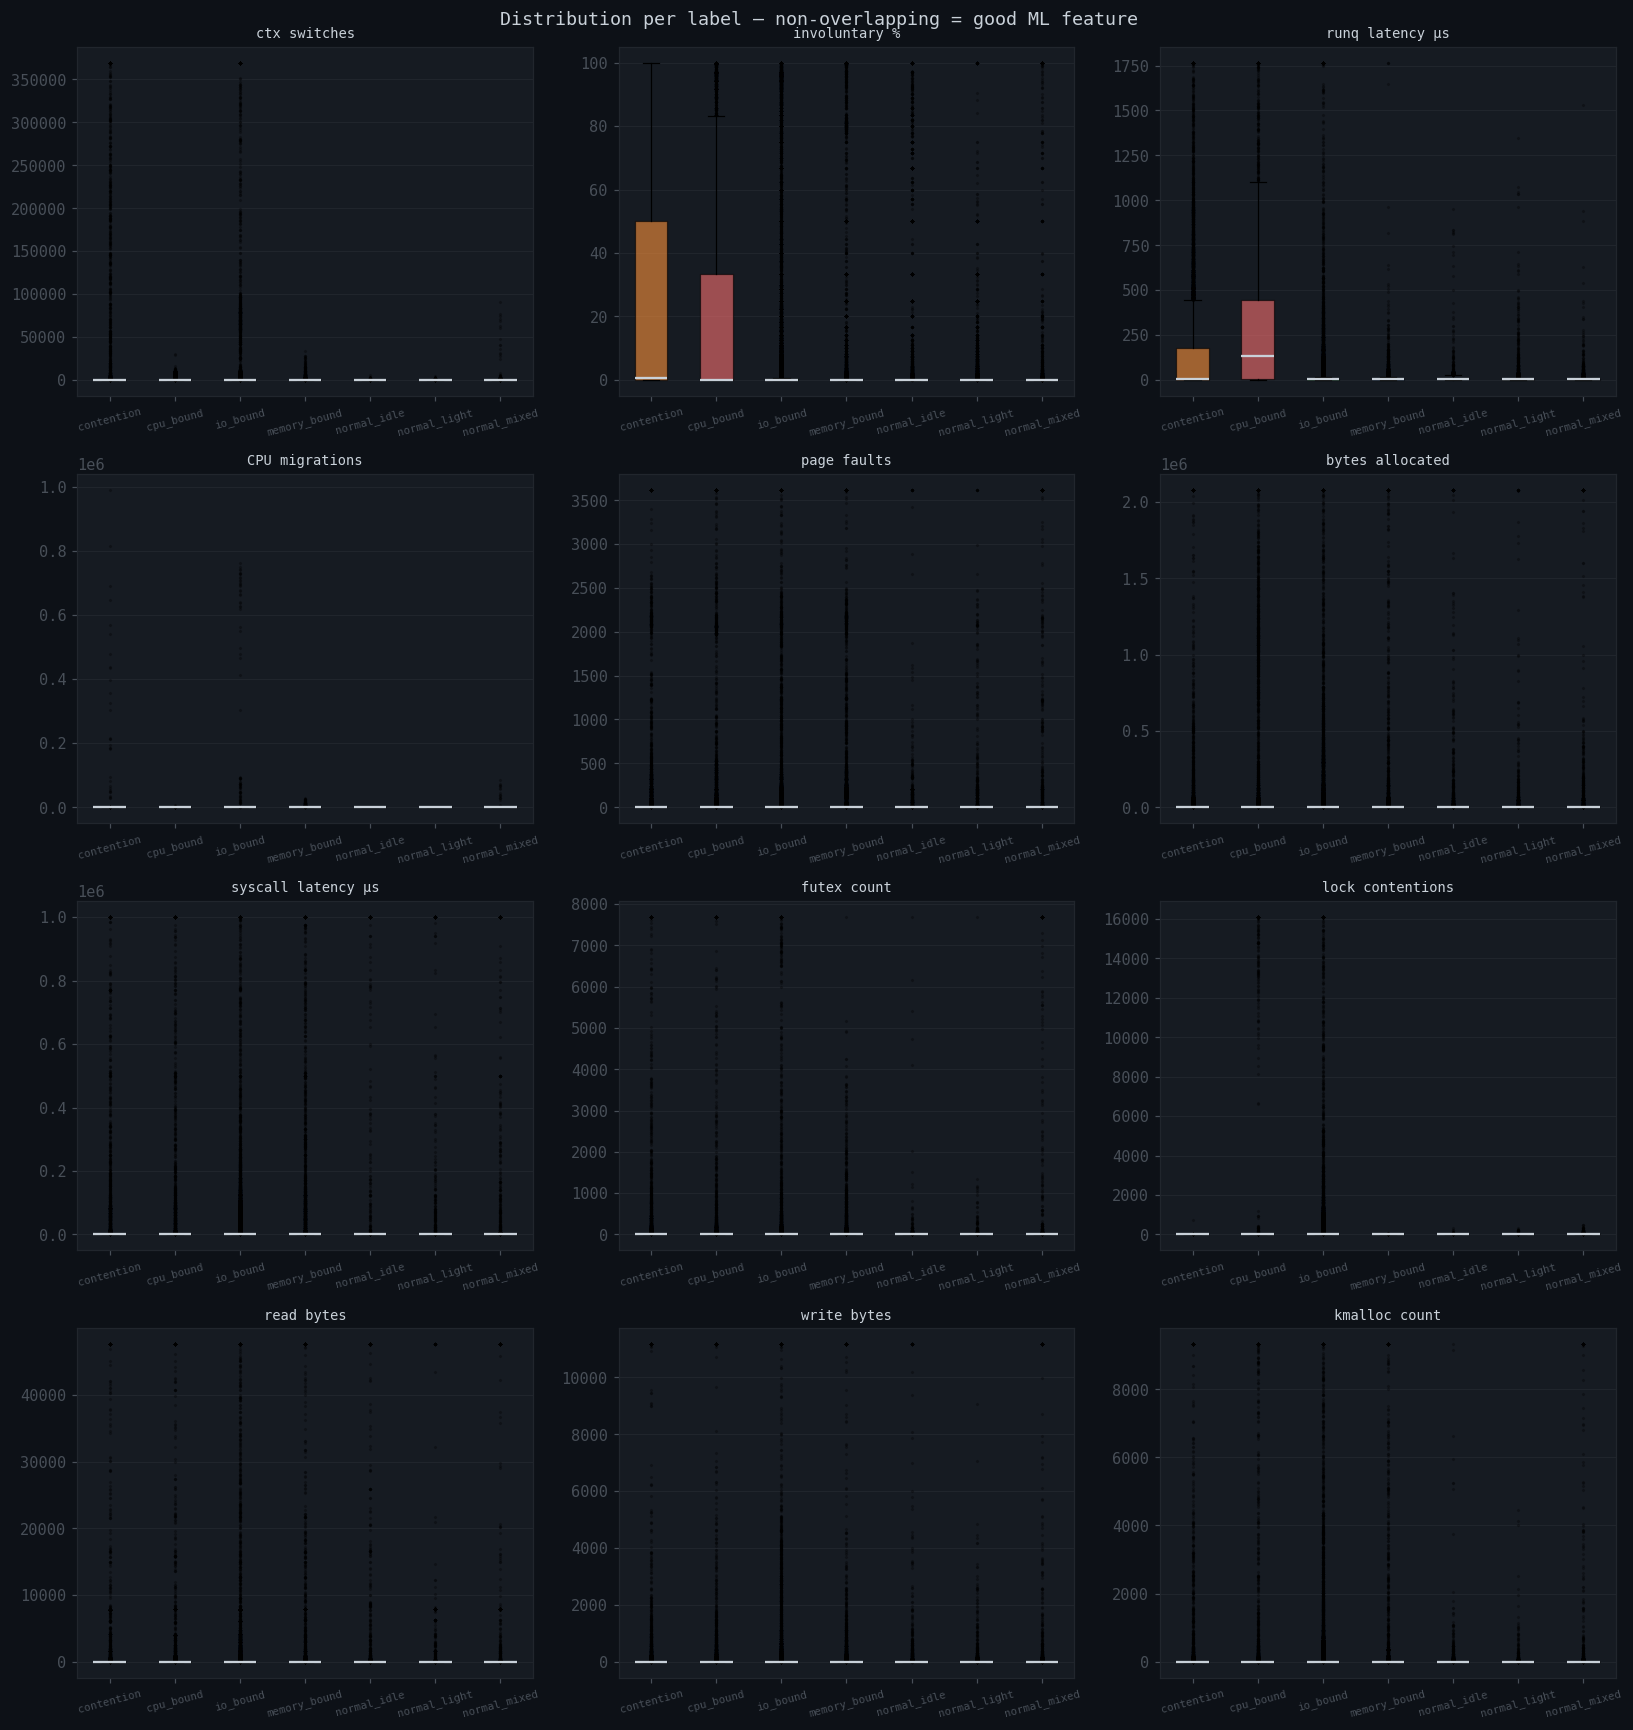

In [44]:
if len(labels) < 2:
    print(f'Need 2+ labels. Currently have: {labels}. Collect more workloads.')
else:
    box_metrics = [
        ('ctx_switches',           'ctx switches'),
        ('involuntary_pct',        'involuntary %'),
        ('avg_runq_latency_us',    'runq latency µs'),
        ('cpu_migrations',         'CPU migrations'),
        ('total_faults',           'page faults'),
        ('total_alloc_bytes',      'bytes allocated'),
        ('avg_syscall_latency_us', 'syscall latency µs'),
        ('futex_count',            'futex count'),
        ('total_lock_contentions', 'lock contentions'),
        ('read_bytes',             'read bytes'),
        ('write_bytes',            'write bytes'),
        ('kmalloc_count',          'kmalloc count'),
    ]
    box_metrics = [(m, l) for m, l in box_metrics if m in df_clean.columns]

    cols = 3
    rows = (len(box_metrics) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    fig.suptitle('Distribution per label — non-overlapping = good ML feature', fontsize=12)
    axes = axes.flatten()

    for i, (col, ylabel) in enumerate(box_metrics):
        ax = axes[i]
        data   = [df_clean[df_clean['label'] == l][col].dropna().values for l in labels]
        colors = [LABEL_COLORS.get(l, MUTED) for l in labels]
        bp = ax.boxplot(data, labels=labels, patch_artist=True,
                        medianprops={'color': TEXT, 'linewidth': 1.5},
                        boxprops={'linewidth': 0.8},
                        whiskerprops={'linewidth': 0.8},
                        capprops={'linewidth': 0.8},
                        flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color); patch.set_alpha(0.6)
        ax.set_title(ylabel, fontsize=9)
        ax.grid(True, axis='y')
        ax.tick_params(axis='x', labelsize=7, rotation=15)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    savefig(fig, '02_boxplots_per_label.png')
    plt.show()

---
## Figure 3 — Bottleneck fingerprint: normalised mean per label

Each label should have a different shape — that shape is its bottleneck fingerprint.  
High CPU pressure = high involuntary%, high ctx_switches.  
Memory bottleneck = high faults, high alloc bytes.  
I/O bottleneck = high syscall latency, high read/write bytes.  
Lock contention = high futex, high lock contentions.

saved → ./plots/03_fingerprint.png


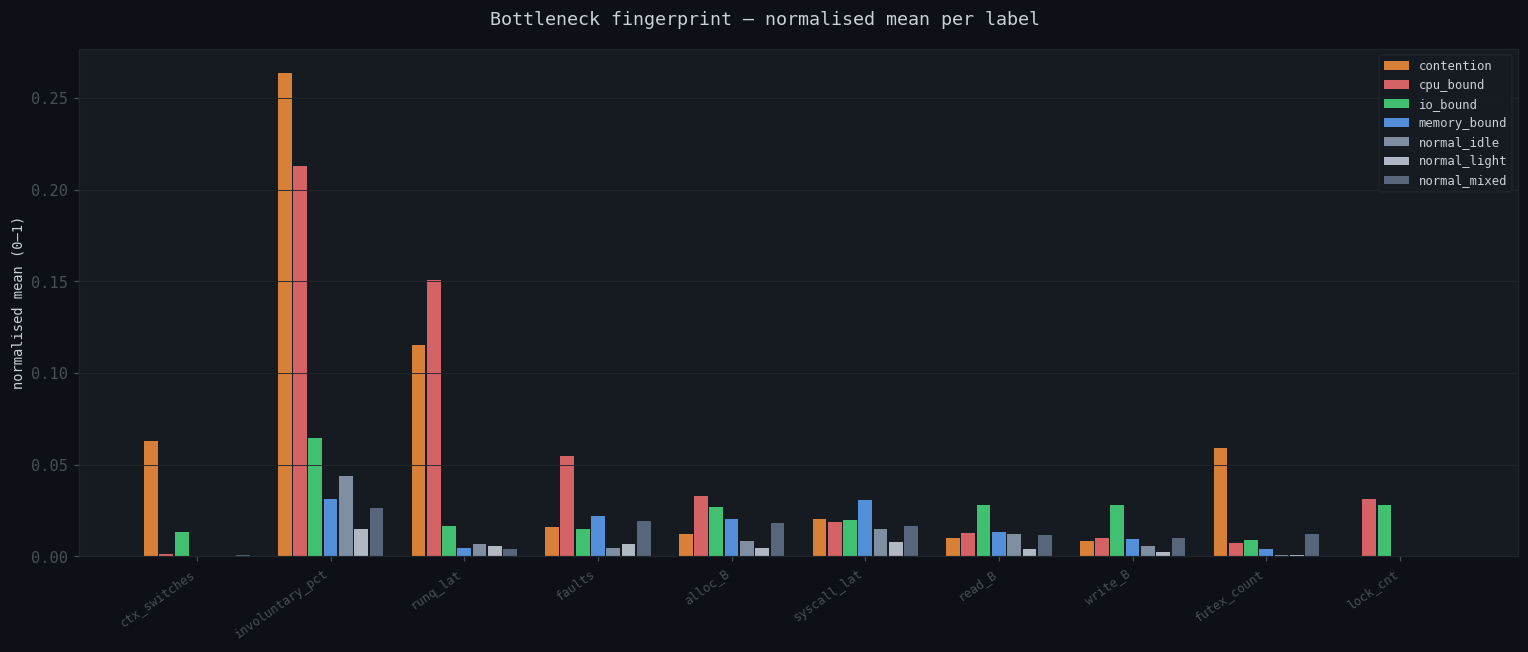

In [45]:
fingerprint_metrics = [
    'ctx_switches', 'involuntary_pct', 'avg_runq_latency_us',
    'total_faults', 'total_alloc_bytes',
    'avg_syscall_latency_us', 'read_bytes', 'write_bytes',
    'futex_count', 'total_lock_contentions',
]
fingerprint_metrics = [m for m in fingerprint_metrics if m in df_clean.columns]

norm = df_clean[fingerprint_metrics].copy()
for col in fingerprint_metrics:
    mn, mx = norm[col].min(), norm[col].max()
    norm[col] = (norm[col] - mn) / (mx - mn + 1e-9)
norm['label'] = df_clean['label'].values

means = norm.groupby('label')[fingerprint_metrics].mean()

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Bottleneck fingerprint — normalised mean per label', fontsize=12)

x = np.arange(len(fingerprint_metrics))
width = 0.8 / max(len(labels), 1)

for i, lbl in enumerate(means.index):
    offset = (i - len(means.index)/2 + 0.5) * width
    ax.bar(x + offset, means.loc[lbl], width=width * 0.9,
           color=LABEL_COLORS.get(lbl, MUTED), alpha=0.85, label=lbl)

short_names = [m.replace('avg_','').replace('_latency_us','_lat')
                .replace('_bytes','_B').replace('total_','').replace('_contentions','_cnt')
                for m in fingerprint_metrics]
ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('normalised mean (0–1)')
ax.legend(loc='upper right')
ax.grid(True, axis='y')

plt.tight_layout()
savefig(fig, '03_fingerprint.png')
plt.show()

---
## Figure 4 — Correlation heatmap

Pairs with correlation > 0.9 are redundant — only one needed for the classifier.

saved → ./plots/04_correlation.png


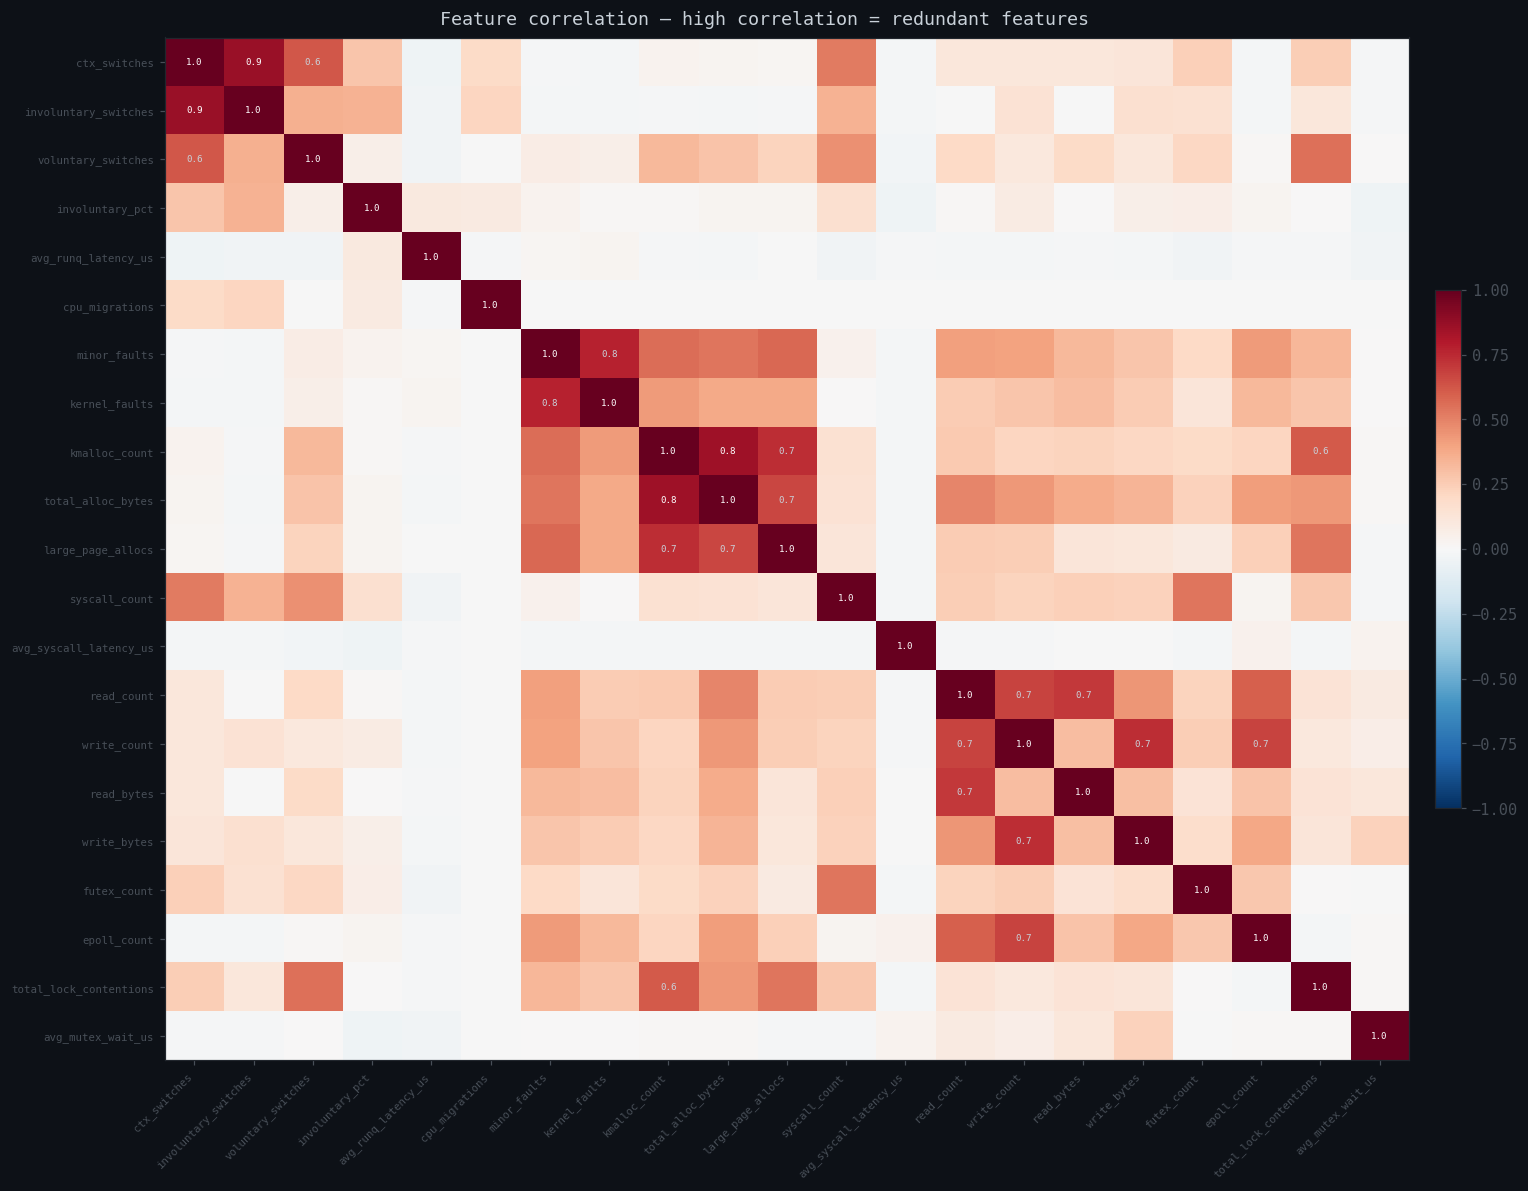

In [46]:
corr_cols = [
    'ctx_switches', 'involuntary_switches', 'voluntary_switches',
    'involuntary_pct', 'avg_runq_latency_us', 'cpu_migrations',
    'minor_faults', 'kernel_faults', 'kmalloc_count',
    'total_alloc_bytes', 'large_page_allocs',
    'syscall_count', 'avg_syscall_latency_us',
    'read_count', 'write_count', 'read_bytes', 'write_bytes',
    'futex_count', 'epoll_count',
    'total_lock_contentions', 'avg_mutex_wait_us',
]
corr_cols = [c for c in corr_cols if c in df_clean.columns]
corr = df_clean[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Feature correlation — high correlation = redundant features', fontsize=12)
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha='right', fontsize=7)
ax.set_yticklabels(corr_cols, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        v = corr.values[i, j]
        if abs(v) > 0.6:
            ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                    fontsize=6, color='white' if abs(v) > 0.8 else TEXT)
plt.tight_layout()
savefig(fig, '04_correlation.png')
plt.show()

---
## Figure 5 — 2D scatter: pairs of metrics, coloured by label

Distinct clouds = separable bottleneck types.  
- cpu_bound: high involuntary%, high runq latency  
- memory_bound: high faults, high alloc bytes  
- io_bound: high syscall latency, high read/write bytes  
- contention: high futex, high lock contentions

saved → ./plots/05_feature_pairs.png


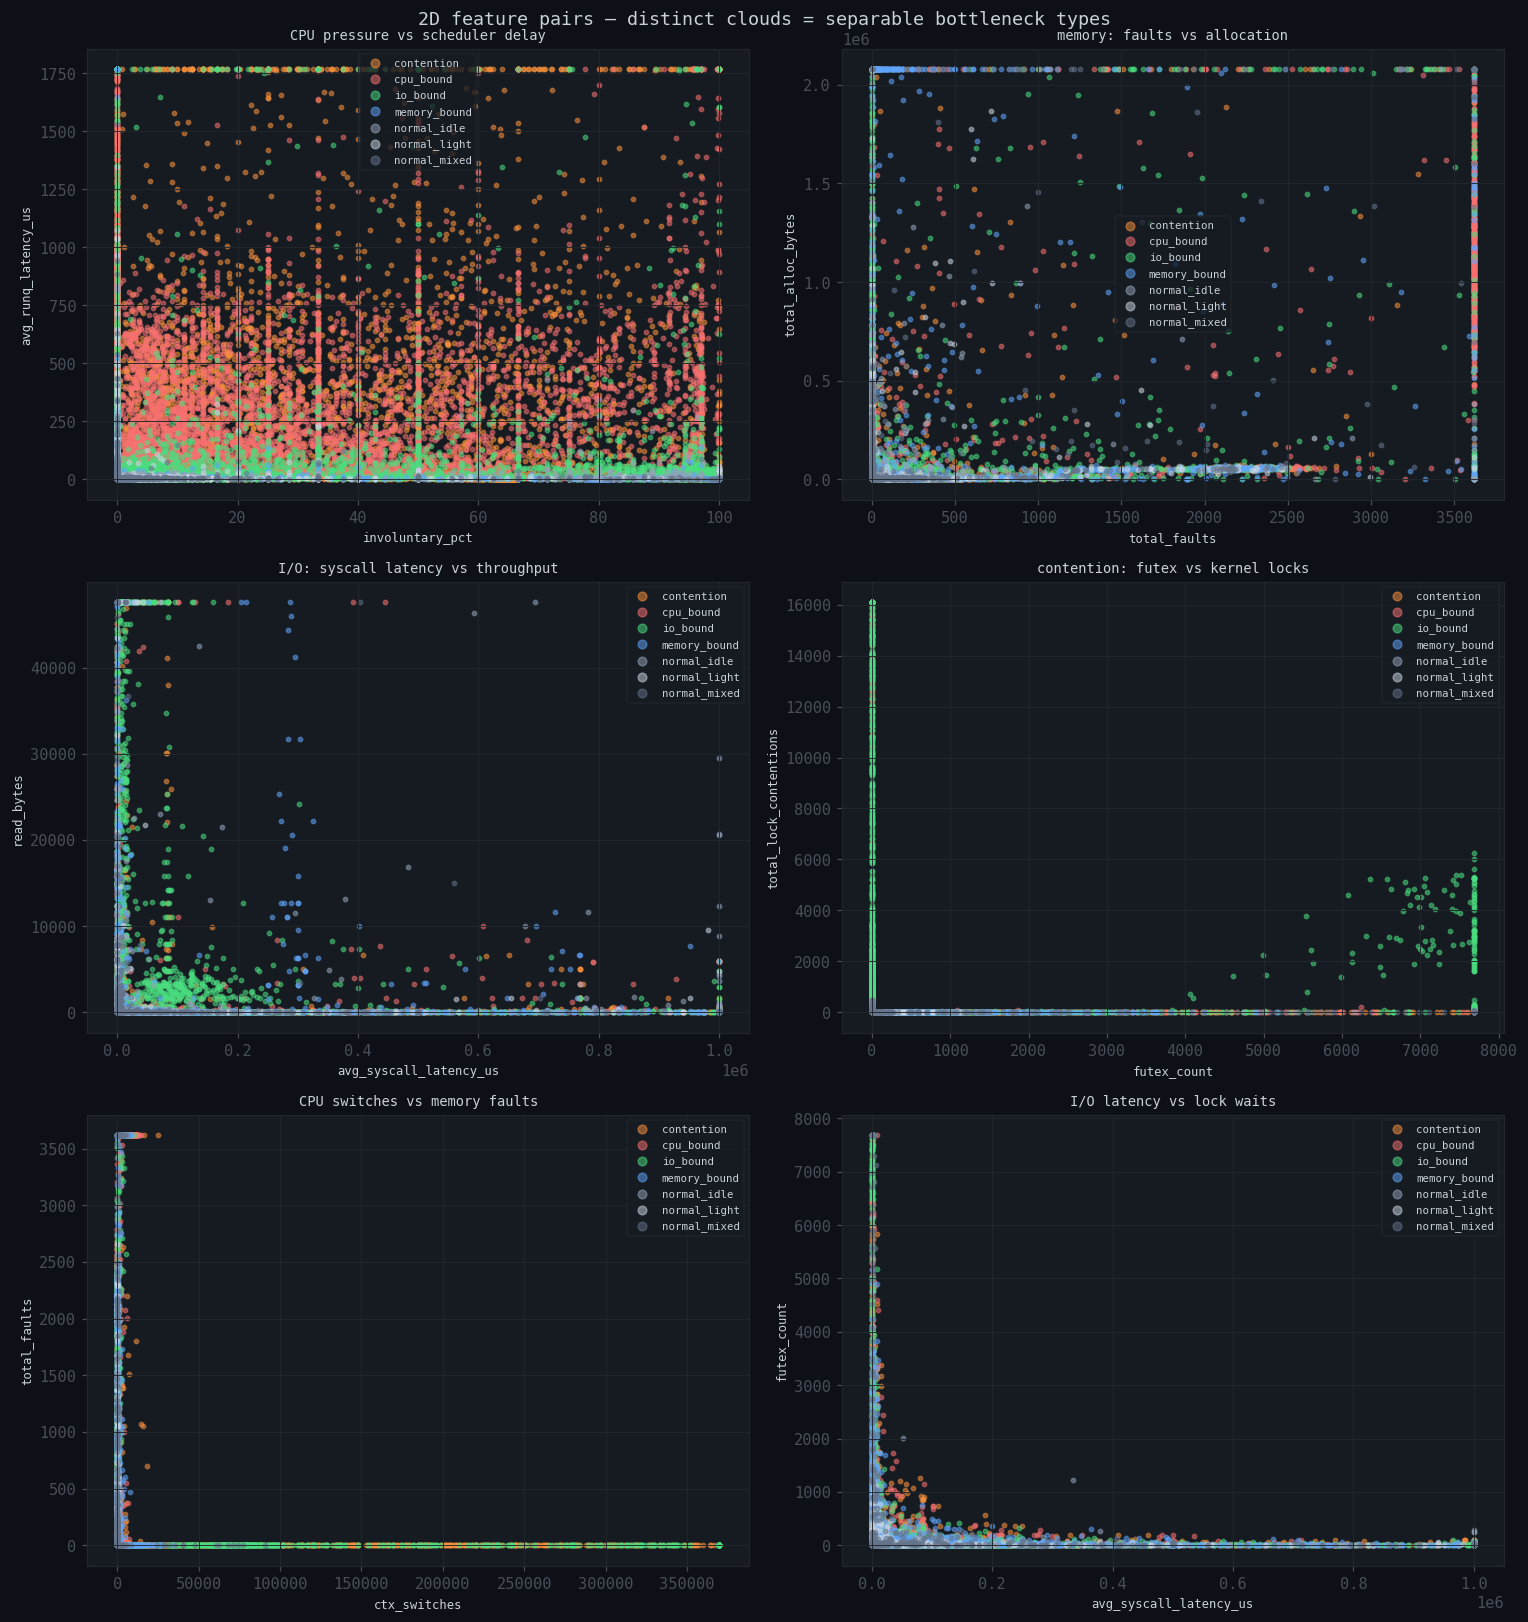

In [47]:
pairs = [
    ('involuntary_pct',        'avg_runq_latency_us',    'CPU pressure vs scheduler delay'),
    ('total_faults',           'total_alloc_bytes',      'memory: faults vs allocation'),
    ('avg_syscall_latency_us', 'read_bytes',             'I/O: syscall latency vs throughput'),
    ('futex_count',            'total_lock_contentions', 'contention: futex vs kernel locks'),
    ('ctx_switches',           'total_faults',           'CPU switches vs memory faults'),
    ('avg_syscall_latency_us', 'futex_count',            'I/O latency vs lock waits'),
]
pairs = [(x, y, t) for x, y, t in pairs if x in df_clean.columns and y in df_clean.columns]

cols = 2
rows = (len(pairs) + 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
fig.suptitle('2D feature pairs — distinct clouds = separable bottleneck types', fontsize=12)
axes = axes.flatten()

for i, (xcol, ycol, title) in enumerate(pairs):
    ax = axes[i]
    for lbl in labels:
        mask = df_clean['label'] == lbl
        ax.scatter(df_clean.loc[mask, xcol], df_clean.loc[mask, ycol],
                   c=LABEL_COLORS.get(lbl, MUTED), s=8, alpha=0.5, label=lbl)
    ax.set_xlabel(xcol, fontsize=8)
    ax.set_ylabel(ycol, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.grid(True)
    ax.legend(fontsize=7, markerscale=2)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
savefig(fig, '05_feature_pairs.png')
plt.show()

---
## Figure 6 — Violin plots: distribution shape per label

Narrow tall violin = tightly clustered values (good signal).  
Wide flat violin = high variance (noisy feature).

saved → ./plots/06_violins.png


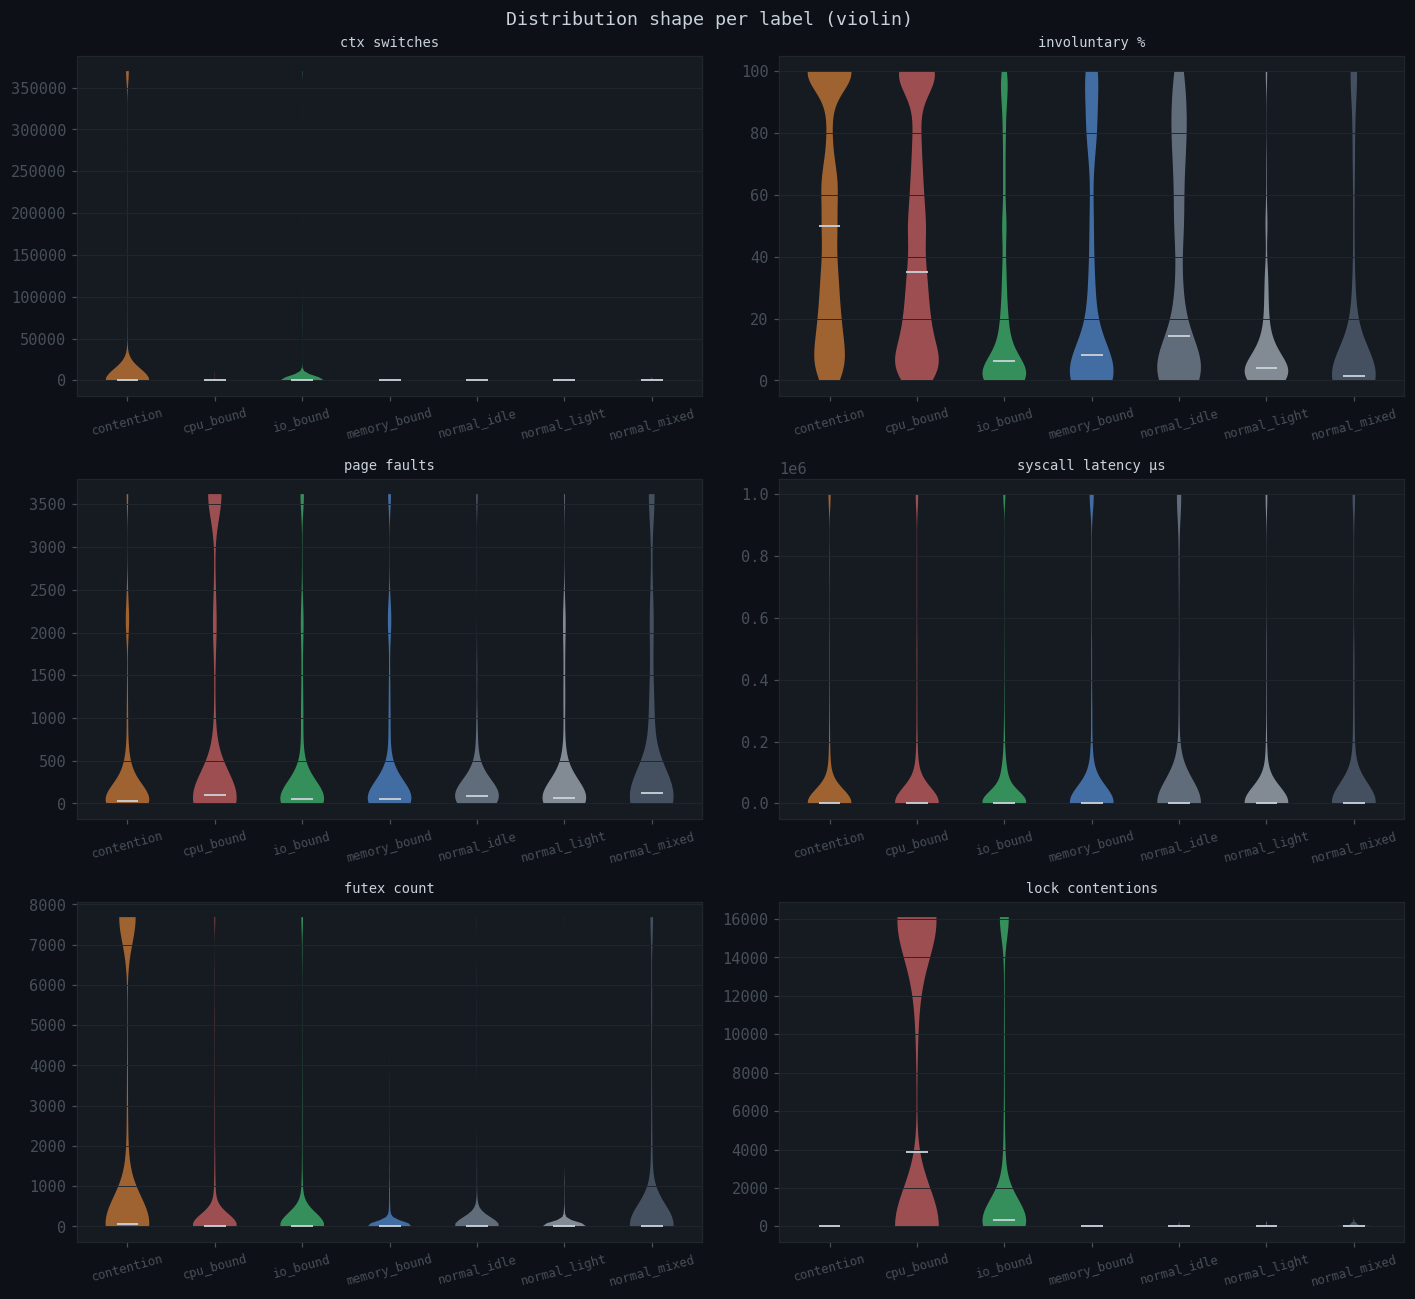

In [48]:
if len(labels) < 2:
    print('Need 2+ labels for violin comparison.')
else:
    violin_metrics = [
        ('ctx_switches',           'ctx switches'),
        ('involuntary_pct',        'involuntary %'),
        ('total_faults',           'page faults'),
        ('avg_syscall_latency_us', 'syscall latency µs'),
        ('futex_count',            'futex count'),
        ('total_lock_contentions', 'lock contentions'),
    ]
    violin_metrics = [(m, l) for m, l in violin_metrics if m in df_clean.columns]

    cols = 2
    rows = (len(violin_metrics) + 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(13, 4 * rows))
    fig.suptitle('Distribution shape per label (violin)', fontsize=12)
    axes = axes.flatten()

    for i, (col, ylabel) in enumerate(violin_metrics):
        ax = axes[i]
        data = [df_clean[df_clean['label'] == l][col].dropna().values for l in labels]
        data = [d[d > 0] if len(d[d > 0]) > 1 else d for d in data]
        try:
            parts = ax.violinplot(data, positions=range(len(labels)),
                                  showmedians=True, showextrema=False)
            for j, (pc, lbl) in enumerate(zip(parts['bodies'], labels)):
                pc.set_facecolor(LABEL_COLORS.get(lbl, MUTED))
                pc.set_alpha(0.6)
            parts['cmedians'].set_color(TEXT)
        except Exception:
            ax.boxplot(data, labels=labels, patch_artist=False)
        ax.set_xticks(range(len(labels)))
        ax.set_xticklabels(labels, fontsize=8, rotation=15)
        ax.set_title(ylabel, fontsize=9)
        ax.grid(True, axis='y')

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    savefig(fig, '06_violins.png')
    plt.show()

---
## Summary stats per label

Mean ± std ± max per feature per label — sanity check before training.
Uses `df_clean` (sparsity-filtered + capped).

In [49]:
summary_cols = [
    'ctx_switches', 'involuntary_pct', 'avg_runq_latency_us',
    'total_faults', 'total_alloc_bytes',
    'avg_syscall_latency_us', 'futex_count', 'total_lock_contentions',
]
summary_cols = [c for c in summary_cols if c in df_clean.columns]

summary = df_clean.groupby('label')[summary_cols].agg(['mean','std','max']).round(1)
display(summary)

ctx_switches                    involuntary_pct               \
                     mean      std       max            mean   std    max   
label                                                                       
contention        23188.5  85177.9  369661.2            26.4  36.9  100.0   
cpu_bound           399.4   1418.4   29949.0            21.3  33.5  100.0   
io_bound           4902.4  36603.7  369661.2             6.4  19.6  100.0   
memory_bound        136.9   1078.1   34040.0             3.1  15.2  100.0   
normal_idle          40.2    154.8    5306.0             4.4  17.0  100.0   
normal_light         47.6    181.2    4678.0             1.5   7.8  100.0   
normal_mixed        284.8   2906.6   90902.0             2.6  14.0  100.0   

             avg_runq_latency_us                total_faults  ...  \
                            mean    std     max         mean  ...   
label                                                         ...   
contention                 203.8  425.7  1766.8         58.1  ...   
cpu_bound                  266.1  327.2  1766.8        198.6  ...   
io_bound                    28.7  155.8  1766.8         53.2  ...   
memory_bound                 8.2   34.6  1766.8         78.5  ...   
normal_idle                 11.5   34.6   949.4         16.2  ...   
normal_light                10.2   45.7  1345.5         23.7  ...   
normal_mixed                 7.2   35.0  1530.0         69.9  ...   

             total_alloc_bytes avg_syscall_latency_us                       \
                           max                   mean       std        max   
label                                                                        
contention           2079665.0                20051.4  120644.2  1000084.7   
cpu_bound            2079665.0                18850.4  116777.5  1000084.7   
io_bound             2079665.0                19641.7  111504.0  1000084.7   
memory_bound         2079665.0                30710.3  153765.9  1000084.7   
normal_idle          2079665.0                14839.2  112629.9  1000084.7   
normal_light         2079665.0                 7647.3   74492.9  1000084.7   
normal_mixed         2079665.0                16713.7  109013.3  1000084.7   

             futex_count               total_lock_contentions                   
                    mean     std   max                   mean     std      max  
label                                                                           
contention         452.5  1741.6  7685                    0.1     6.0    752.0  
cpu_bound           53.3   488.2  7685                  505.5  2763.3  16099.8  
io_bound            67.4   614.3  7685                  449.4  2415.4  16099.8  
memory_bound        30.2   229.7  7685                    0.2     1.4     54.0  
normal_idle          7.1   155.2  7685                    0.4     6.8    340.0  
normal_light         4.6    96.4  7685                    0.6     9.3    303.0  
normal_mixed        92.2   728.2  7685                    3.2    24.6    478.0  

[7 rows x 24 columns]

---
## Sparsity check
What fraction of clean rows have non-zero values for key features.

In [50]:
print('Non-zero % in df_clean:')
for col in ['ctx_switches', 'minor_faults', 'total_alloc_bytes',
            'avg_syscall_latency_ns', 'futex_count', 'total_lock_contentions']:
    if col in df_clean.columns:
        pct = (df_clean[col] > 0).mean() * 100
        print(f'  {col:<35} {pct:.1f}%')

print('\nNon-zero counts per label for key sparse features:')
for col in ['minor_faults', 'total_alloc_bytes', 'avg_syscall_latency_ns', 'futex_count']:
    if col in df_clean.columns:
        print(f'\n{col}:')
        print(df_clean[df_clean[col] > 0]['label'].value_counts().to_string())

Non-zero % in df_clean:
  ctx_switches                        90.8%
  minor_faults                        13.1%
  total_alloc_bytes                   19.7%
  avg_syscall_latency_ns              23.1%
  futex_count                         14.9%
  total_lock_contentions              7.8%

Non-zero counts per label for key sparse features:

minor_faults:
label
io_bound        3377
cpu_bound       3082
memory_bound    2938
contention      2358
normal_mixed     582
normal_light     548
normal_idle      493

total_alloc_bytes:
label
io_bound        7400
memory_bound    3718
cpu_bound       3395
contention      2895
normal_mixed     923
normal_light     874
normal_idle      799

avg_syscall_latency_ns:
label
io_bound        8429
memory_bound    4644
contention      4194
cpu_bound       3262
normal_mixed    1033
normal_light    1012
normal_idle      968

futex_count:
label
io_bound        4430
memory_bound    3408
contention      3326
cpu_bound       2182
normal_mixed     744
normal_light     

In [51]:
# check: among memory_bound rows only, what % have non-zero alloc bytes
mem = df_clean[df_clean['label'] == 'memory_bound']
active = mem[mem['total_alloc_bytes'] > 0]
print(active.groupby('comm')[['total_alloc_bytes', 'minor_faults', 'ctx_switches']].mean().sort_values('total_alloc_bytes', ascending=False).head(20))

                 total_alloc_bytes  minor_faults  ctx_switches
comm                                                          
stress-ng-vm          2.063038e+06   3477.753913     78.869565
stress-ng-mmap        1.896305e+06     66.119266    469.972477
systemd-oomd          1.655253e+06      0.000000     16.760000
zen                   1.626003e+06    543.380000   1290.365854
gnome-shell           1.503601e+06   2787.747692   1922.846154
kworker/9:1H          8.110080e+05      0.000000    217.000000
ptyxis                4.805323e+05      1.206897    202.862069
kworker/3:1H          3.850240e+05      0.000000     98.000000
NetworkManager        3.274655e+05      0.000000     30.648649
kworker/13:1H         2.416640e+05      0.000000     62.000000
kworker/10:1H         1.822720e+05      0.000000     83.500000
kworker/0:1H          1.556480e+05      0.000000    115.000000
kworker/7:1H          1.351680e+05      0.000000     64.000000
wpa_supplicant        1.239406e+05      0.000000     10

In [52]:
df_session = df_clean.groupby(['timestamp_s', 'label']).agg({
    'ctx_switches':          'sum',
    'involuntary_switches':  'sum',
    'involuntary_pct':       'mean',
    'avg_runq_latency_us':   'mean',
    'total_faults':          'max',   # max picks up the stress worker
    'total_alloc_bytes':     'max',   # not diluted by background zeros
    'avg_syscall_latency_us':'mean',
    'futex_count':           'sum',
    'total_lock_contentions':'sum',
}).reset_index()

print(df_session.groupby('label')[['total_faults','total_alloc_bytes']].mean().round(0))

              total_faults  total_alloc_bytes
label                                        
contention          3619.0          2079665.0
cpu_bound           3619.0          2079665.0
io_bound            3619.0          2079665.0
memory_bound        3619.0          2079665.0
normal_idle         1915.0          2079665.0
normal_light        3619.0          2079665.0
normal_mixed        3619.0          2079665.0


In [53]:
# session-level aggregation — correct granularity for this problem
df_session = df_clean.groupby(['timestamp_s', 'label']).agg({
    'ctx_switches':           'sum',
    'involuntary_switches':   'sum',
    'voluntary_switches':     'sum',
    'involuntary_pct':        'mean',
    'avg_runq_latency_us':    'mean',
    'cpu_migrations':         'sum',
    'minor_faults':           'sum',
    'kernel_faults':          'sum',
    'kmalloc_count':          'sum',
    'total_alloc_bytes':      'sum',
    'large_page_allocs':      'sum',
    'syscall_count':          'sum',
    'avg_syscall_latency_us': 'mean',
    'read_count':             'sum',
    'write_count':            'sum',
    'mmap_count':             'sum',
    'read_bytes':             'sum',
    'write_bytes':            'sum',
    'futex_count':            'sum',
    'avg_futex_latency_us':   'mean',
    'epoll_count':            'sum',
    'total_lock_contentions': 'sum',
    'avg_mutex_wait_us':      'mean',
    'total_faults':           'sum',
}).reset_index()

print(df_session['label'].value_counts())
print(f'\nTotal sessions: {len(df_session)}')
print(df_session.groupby('label')[['ctx_switches','total_alloc_bytes',
                                    'involuntary_pct','avg_runq_latency_us']].mean().round(1))

label
memory_bound    6
cpu_bound       5
io_bound        5
contention      5
normal_idle     2
normal_mixed    1
normal_light    1
Name: count, dtype: int64

Total sessions: 25
              ctx_switches  total_alloc_bytes  involuntary_pct  \
label                                                            
contention      73716103.7         78735848.4             26.9   
cpu_bound        1199715.6        204836770.8             18.3   
io_bound        31618635.0        356942940.6              7.4   
memory_bound      402036.2        123950504.6              3.2   
normal_idle       149298.0         64806306.6              3.0   
normal_light      376212.0         73069241.6              1.5   
normal_mixed     1615805.0        216235536.3              2.6   

              avg_runq_latency_us  
label                              
contention                  201.7  
cpu_bound                   241.0  
io_bound                     35.7  
memory_bound                  8.1  
normal_idle

saved → ./plots/07_feature_importance.png


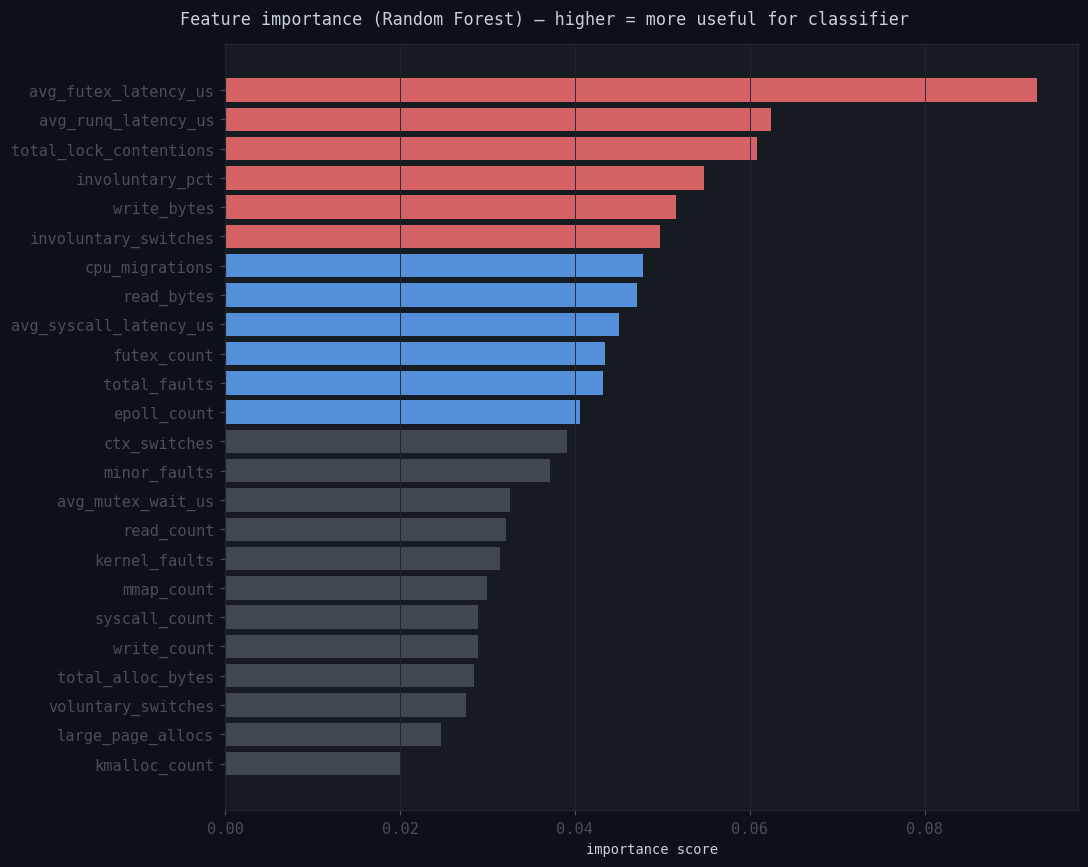


Top 10 features:
avg_futex_latency_us      0.092889
avg_runq_latency_us       0.062396
total_lock_contentions    0.060817
involuntary_pct           0.054770
write_bytes               0.051518
involuntary_switches      0.049754
cpu_migrations            0.047826
read_bytes                0.047113
avg_syscall_latency_us    0.044982
futex_count               0.043463
dtype: float64


In [54]:
# ── Cell: Feature importance preview using Random Forest ─────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

feature_cols = [
    'ctx_switches', 'involuntary_switches', 'voluntary_switches',
    'involuntary_pct', 'avg_runq_latency_us', 'cpu_migrations',
    'minor_faults', 'kernel_faults', 'kmalloc_count',
    'total_alloc_bytes', 'large_page_allocs',
    'syscall_count', 'avg_syscall_latency_us',
    'read_count', 'write_count', 'read_bytes', 'write_bytes',
    'mmap_count', 'futex_count', 'avg_futex_latency_us',
    'epoll_count', 'total_lock_contentions', 'avg_mutex_wait_us',
    'total_faults',
]
feature_cols = [c for c in feature_cols if c in df_clean.columns]

X = df_session[feature_cols].fillna(0)
y = df_session['label']

le = LabelEncoder()
y_enc = le.fit_transform(y)

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X, y_enc)

importances = pd.Series(rf.feature_importances_, index=feature_cols)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Feature importance (Random Forest) — higher = more useful for classifier', fontsize=11)
colors = ['#f87171' if v > importances.quantile(0.75) else '#60a5fa' 
          if v > importances.quantile(0.5) else MUTED for v in importances]
ax.barh(importances.index, importances.values, color=colors, alpha=0.85)
ax.set_xlabel('importance score')
ax.grid(True, axis='x')
plt.tight_layout()
savefig(fig, '07_feature_importance.png')
plt.show()

print('\nTop 10 features:')
print(importances.sort_values(ascending=False).head(10))

In [55]:
# ── Cell: Quick classification report ────────────────────────────────────────
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(rf, X, y_enc, cv=cv, scoring='f1_macro')
print(f'5-fold cross-val F1 macro: {scores.mean():.3f} ± {scores.std():.3f}')
print(f'Per-fold: {scores.round(3)}')

# full report on all data (optimistic — just for feature diagnostic)
y_pred = rf.predict(X)
print('\nClassification report (training data — optimistic):')
print(classification_report(y_enc, y_pred, target_names=le.classes_))

5-fold cross-val F1 macro: 0.551 ± 0.282
Per-fold: [0.333 0.467 0.222 0.733 1.   ]

Classification report (training data — optimistic):
              precision    recall  f1-score   support

  contention       1.00      1.00      1.00         5
   cpu_bound       1.00      1.00      1.00         5
    io_bound       1.00      1.00      1.00         5
memory_bound       1.00      1.00      1.00         6
 normal_idle       1.00      1.00      1.00         2
normal_light       1.00      1.00      1.00         1
normal_mixed       1.00      1.00      1.00         1

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



saved → ./plots/08_confusion_matrix.png


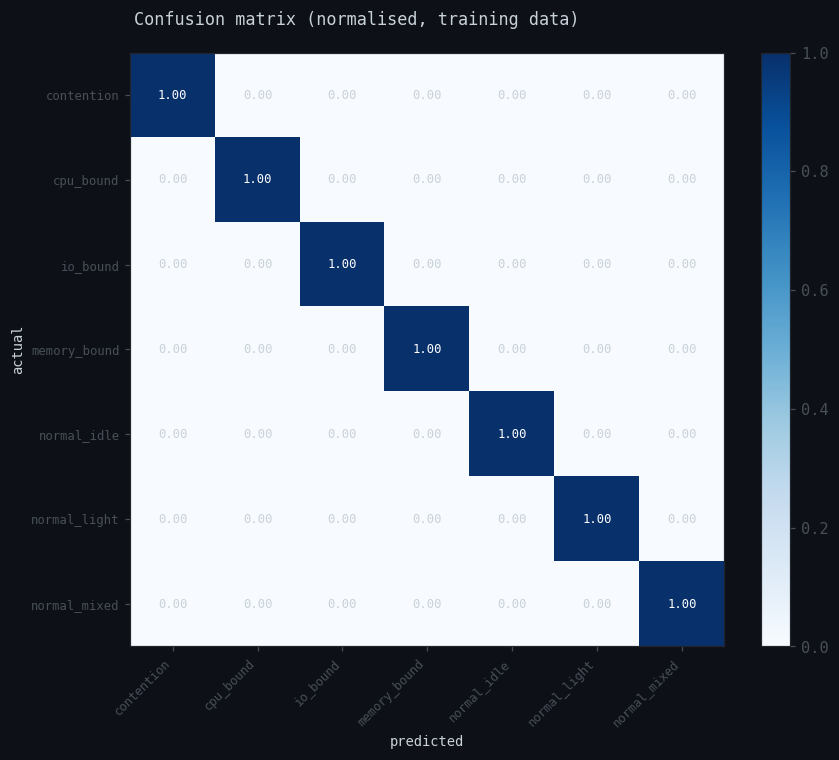

In [56]:
# ── Cell: Confusion matrix ────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_enc, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle('Confusion matrix (normalised, training data)', fontsize=11)
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(len(le.classes_)))
ax.set_yticks(range(len(le.classes_)))
ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(le.classes_, fontsize=8)
ax.set_xlabel('predicted')
ax.set_ylabel('actual')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for i in range(len(le.classes_)):
    for j in range(len(le.classes_)):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}', ha='center', va='center',
                fontsize=8, color='white' if cm_norm[i,j] > 0.5 else TEXT)
plt.tight_layout()
savefig(fig, '08_confusion_matrix.png')
plt.show()